# Candidate Dataset 2 Investigation: Dapoli/Karjat Agro-Meteorological Dataset
## Paper Reference: PMC8444092 / PeerJ Computer Science (Patil & Kumar, 2021)
### Objective: Evaluate Candidate Dataset 2 for Multiclass Rice Disease Risk Prediction (Semester 7)

---

### Executive Context
In Semester 7, our primary goal is to **predict the most likely rice disease directly from agro-meteorological/environmental conditions**, preferably formulated as a multiclass classification problem.

The published study:
> **Patil, R. R., & Kumar, S. (2021).** *Rice crop disease prediction across diverse agro-meteorological conditions using an artificial intelligence approach.* **PeerJ Computer Science**, 7, e687. [DOI: 10.7717/peerj-cs.687](https://doi.org/10.7717/peerj-cs.687) / [PMC8444092](https://pmc.ncbi.nlm.nih.gov/articles/PMC8444092/)

claims to predict 5 classes of rice crop conditions:
1. **Class 1:** Healthy
2. **Class 2:** Rice Blast (*Magnaporthe oryzae*)
3. **Class 3:** Bacterial Blight (*Xanthomonas oryzae* pv. *oryzae*)
4. **Class 4:** Brown Spot (*Bipolaris oryzae*)
5. **Class 5:** False Smut (*Ustilaginoidea virens*)

This notebook conducts a rigorous, independent empirical audit of the public data and code provided in the paper's open-access supplementary files (`peerj-cs-07-687-s001.csv` and `peerj-cs-07-687-s002.ipynb`).

## 1. Data Ingestion & Metadata Audit
We load the raw supplementary CSV file `ml-service/data/raw/peerj-cs-07-687-s001.csv` directly downloaded from the PMC repository.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# Load raw supplementary dataset
raw_csv_path = '../data/raw/peerj-cs-07-687-s001.csv'
df_raw = pd.read_csv(raw_csv_path)

print(f"Loaded {raw_csv_path}")
print(f"Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\nColumns:", df_raw.columns.tolist())
df_raw.head(5)

Loaded ../data/raw/peerj-cs-07-687-s001.csv
Shape: 1642 rows, 11 columns

Columns: ['Location', 'Address', 'Period', 'Maximum Temperature', 'Minimum Temperature', 'Temperature', 'Heat Index', 'Precipitation', 'Wind Speed', 'Cloud Cover', 'Relative Humidity']


,Location,Address,Period,Maximum Temperature,Minimum Temperature,Temperature,Heat Index,Precipitation,Wind Speed,Cloud Cover,Relative Humidity
0,"Karjat, MH, India","Karjat, MH, India",Week 1 (Jan) 2000,33.1,17.5,25.4,32.3,0.0,14.8,0.3,48.93
1,"Karjat, MH, India","Karjat, MH, India",Week 2 (Jan) 2000,33.1,11.2,24.8,32.0,0.0,18.4,2.4,42.30
2,"Karjat, MH, India","Karjat, MH, India",Week 3 (Jan) 2000,31.1,11.2,24.3,31.9,0.0,22.3,5.5,57.20
3,"Karjat, MH, India","Karjat, MH, India",Week 4 (Jan) 2000,37.1,17.2,26.3,39.4,0.0,22.3,7.6,53.69
4,"Karjat, MH, India","Karjat, MH, India",Week 5 (Jan) 2000,34.1,17.3,25.9,32.8,0.0,18.4,1.1,44.75


## 2. Geographic & Location Verification
The paper's narrative explicitly states:
> *"The dataset was collected for Dapoli taluka of Ratnagiri district (Maharashtra, India) which is one of the high productivity districts for rice."*

Let us examine the actual `Location` and `Address` columns in the official supplementary CSV.

In [2]:
print("Unique Location values:")
print(df_raw['Location'].value_counts())
print("\nUnique Address values:")
print(df_raw['Address'].value_counts())

Unique Location values:
Location
Karjat, MH, India    1642
Name: count, dtype: int64

Unique Address values:
Address
Karjat, MH, India    1642
Name: count, dtype: int64


### Finding 1: Geographic Discrepancy
- The published paper text describes the study area as **Dapoli taluka, Ratnagiri district** (South Konkan).
- However, the actual supplementary CSV records **100% of rows (1,642 / 1,642)** as **`Karjat, MH, India`** (Raigad district, North Konkan, ~150 km north of Dapoli).
- Karjat is home to the Regional Agricultural Research Station (RARS Karjat) under Dr. BSKKV Dapoli. While both belong to the Konkan agro-climatic zone, the published dataset is geographically located at Karjat, not Dapoli.

## 3. Temporal Coverage & Continuity Analysis
The `Period` column contains alphanumeric strings such as `Week 1 (Jan) 2000`. We parse this column to analyze temporal coverage, continuity, and identify any duplicate weeks.

In [3]:
def parse_period(p):
    m = re.match(r'Week\s+(\d+)\s+\((\w+)\)\s+(\d{4})', str(p))
    if m:
        return int(m.group(1)), m.group(2), int(m.group(3))
    return np.nan, np.nan, np.nan

df_raw['Week'], df_raw['Month'], df_raw['Year'] = zip(*df_raw['Period'].apply(parse_period))

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_raw['Month'] = pd.Categorical(df_raw['Month'], categories=month_order, ordered=True)

print(f"Temporal Range: {int(df_raw['Year'].min())} to {int(df_raw['Year'].max())} ({df_raw['Year'].nunique()} consecutive years)")
print(f"Total Weeks Recorded: {len(df_raw)}")
print(f"Unique Period strings: {df_raw['Period'].nunique()}")

# Check for duplicate periods
dup_periods = df_raw[df_raw['Period'].duplicated(keep=False)]
print(f"\nDuplicate Period rows: {len(dup_periods)}")
if len(dup_periods) > 0:
    print(dup_periods[['Period', 'Maximum Temperature', 'Relative Humidity', 'Precipitation']])

Temporal Range: 1989 to 2019 (31 consecutive years)
Total Weeks Recorded: 1642
Unique Period strings: 1641

Duplicate Period rows: 2
                Period  Maximum Temperature  Relative Humidity  Precipitation
689  Week 2 (Jan) 2013                 29.3              66.62            0.0
691  Week 2 (Jan) 2013                 33.1              51.16            0.0


In [4]:
# Verify records per year
yearly_counts = df_raw['Year'].value_counts().sort_index()
print("Records per year (1989-2019):")
print(yearly_counts)

Records per year (1989-2019):
Year
1989    53
1990    53
1991    53
1992    53
1993    53
1994    53
1995    53
1996    53
1997    53
1998    53
1999    53
2000    53
2001    53
2002    53
2003    53
2004    53
2005    53
2006    53
2007    53
2008    53
2009    53
2010    53
2011    53
2012    53
2013    54
2014    53
2015    51
2016    53
2017    53
2018    53
2019    53
Name: count, dtype: int64


### Finding 2: Temporal Characteristics
- **Span:** 31 consecutive years (1989 to 2019).
- **Weekly Structure:** Each year typically contains 53 weeks (reflecting standard 52/53 meteorological weeks), except:
  - 2013 contains 54 records (due to a duplicate entry for `Week 2 (Jan) 2013` at rows 689 and 691).
  - 2015 contains 51 records (2 missing weeks).
- **Total sample count:** Exactly **1,642 weekly records** (paper Table 1 reports 1,643 instances, which includes the header).

## 4. Meteorological Feature Distributions & Seasonality
Candidate Dataset 2 includes 8 numerical weather parameters:
1. `Maximum Temperature` (°C)
2. `Minimum Temperature` (°C)
3. `Temperature` (°C)
4. `Heat Index` (°C)
5. `Precipitation` (mm)
6. `Wind Speed` (km/h)
7. `Cloud Cover` (%)
8. `Relative Humidity` (%)

In [5]:
weather_features = [
    'Maximum Temperature', 'Minimum Temperature', 'Temperature',
    'Heat Index', 'Precipitation', 'Wind Speed', 'Cloud Cover', 'Relative Humidity'
]

summary_stats = df_raw[weather_features].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary_stats['IQR'] = summary_stats['75%'] - summary_stats['25%']
summary_stats['Missing'] = df_raw[weather_features].isnull().sum()
summary_stats

,count,mean,std,min,25%,50%,75%,max,IQR,Missing
Maximum Temperature,1642.0,33.439769,2.714193,24.00,31.1000,33.100,35.1000,42.20,4.000,0
Minimum Temperature,1642.0,19.421985,4.524197,0.90,15.9000,21.100,22.7000,28.30,6.800,0
Temperature,1642.0,27.002497,2.276764,18.60,25.8000,27.200,28.6000,32.20,2.800,0
Heat Index,1642.0,36.820341,4.025021,27.10,34.1000,36.900,39.3000,53.80,5.200,0
Precipitation,1642.0,54.449038,119.389226,0.00,0.0000,0.100,45.8300,959.24,45.830,0
Wind Speed,1642.0,22.672594,11.908006,3.60,18.4000,22.300,25.9000,179.60,7.500,0
Cloud Cover,1642.0,40.601157,30.575166,0.00,13.1000,32.300,69.5000,97.20,56.400,0
Relative Humidity,1642.0,66.713965,12.470943,31.75,57.0525,65.265,78.0075,93.26,20.955,0


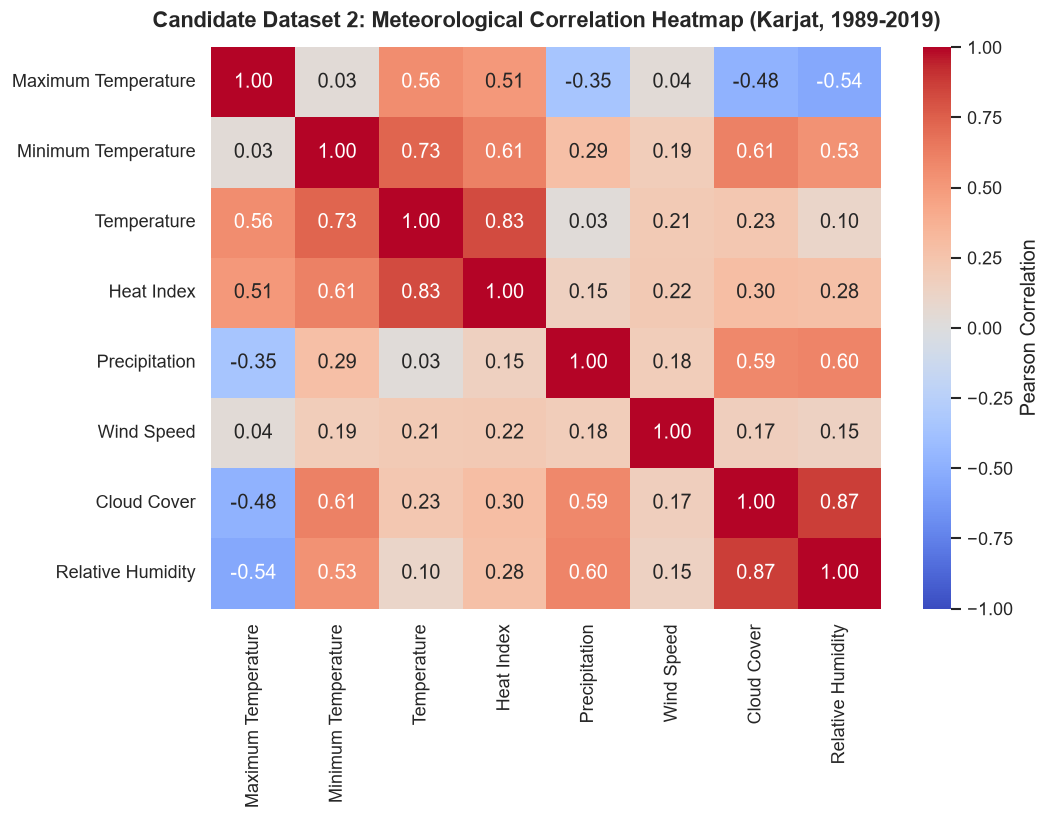

In [6]:
# Correlation matrix among meteorological predictors
plt.figure(figsize=(9, 7))
corr_matrix = df_raw[weather_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={'label': 'Pearson Correlation'})
plt.title("Candidate Dataset 2: Meteorological Correlation Heatmap (Karjat, 1989-2019)", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

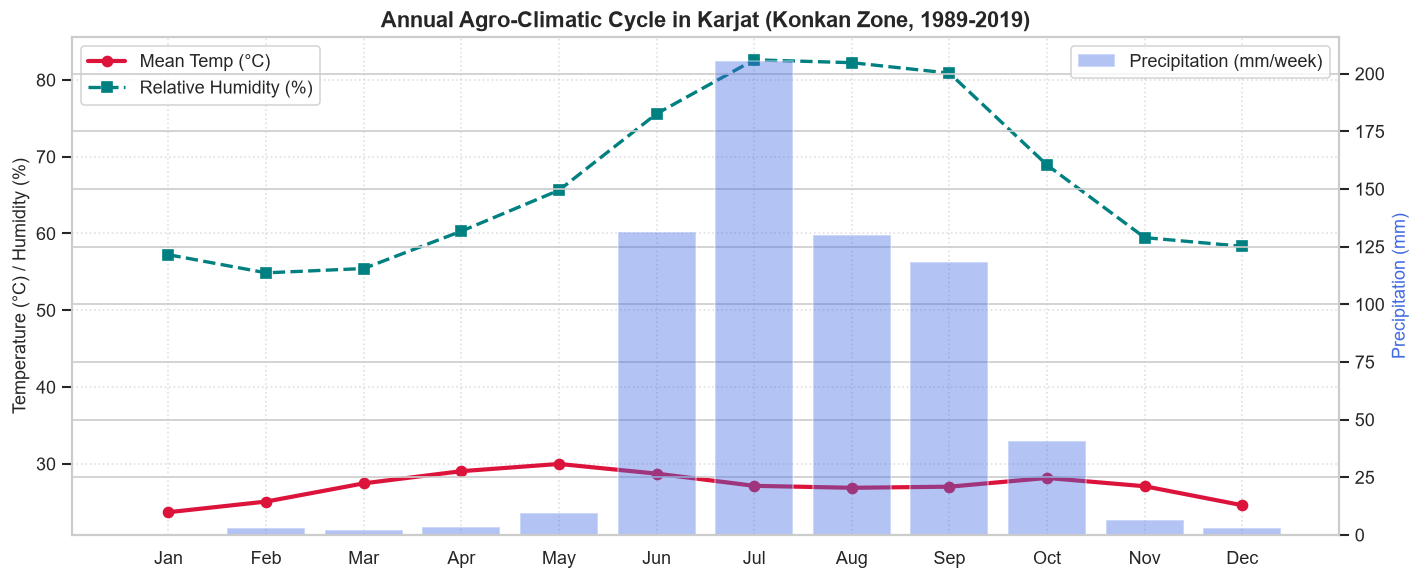

In [7]:
# Monthly Agro-Climatic Cycle
monthly_means = df_raw.groupby('Month', observed=False)[weather_features].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(monthly_means.index, monthly_means['Temperature'], color='crimson', marker='o', linewidth=2.5, label='Mean Temp (°C)')
ax1.plot(monthly_means.index, monthly_means['Relative Humidity'], color='teal', marker='s', linewidth=2, linestyle='--', label='Relative Humidity (%)')
ax2.bar(monthly_means.index, monthly_means['Precipitation'], color='royalblue', alpha=0.4, label='Precipitation (mm/week)')

ax1.set_ylabel('Temperature (°C) / Humidity (%)', fontsize=11)
ax2.set_ylabel('Precipitation (mm)', fontsize=11, color='royalblue')
ax1.set_title("Annual Agro-Climatic Cycle in Karjat (Konkan Zone, 1989-2019)", fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Critical Audit: Disease Classes and Target Availability
The paper states:
> *"The dataset involves predicting the occurrence of five different classes of rice diseases based on the weather parameters in the district... Class 1—Healthy, Class 2—Rice Blast, Class 3—Bacterial Blight, Class 4—Brown Spot, Class 5—False Smut."*

Let us systematically search for any disease column, classification label, or target attribute in the dataset.

In [8]:
# Search for any target or disease column
disease_keywords = ['disease', 'class', 'label', 'target', 'blast', 'blight', 'spot', 'smut', 'healthy', 'pest']
matching_cols = [c for c in df_raw.columns if any(k in c.lower() for k in disease_keywords)]

print(f"Matching target columns found in raw CSV: {matching_cols}")
print(f"Total columns in dataset: {len(df_raw.columns)}")
print(f"All columns: {df_raw.columns.tolist()}")

Matching target columns found in raw CSV: []
Total columns in dataset: 14
All columns: ['Location', 'Address', 'Period', 'Maximum Temperature', 'Minimum Temperature', 'Temperature', 'Heat Index', 'Precipitation', 'Wind Speed', 'Cloud Cover', 'Relative Humidity', 'Week', 'Month', 'Year']


### Finding 3: Complete Absence of Disease Target Labels
- The public supplementary dataset `peerj-cs-07-687-s001.csv` contains **zero disease labels**.
- There is **no multiclass target column**, no binary disease presence column, and no continuous disease severity metric.
- The file is **exclusively an agro-meteorological weather dataset**.

## 6. Audit of Supplemental Code (`peerj-cs-07-687-s002.ipynb`)
We now inspect the authors' official supplementary Jupyter notebook to investigate how the authors conducted their modeling and where the multiclass classification was executed.

In [9]:
import json

nb_path = '../data/raw/peerj-cs-07-687-s002.ipynb'
with open(nb_path, 'r', encoding='utf-8') as f:
    author_nb = json.load(f)

print(f"Supplementary Notebook: {nb_path}")
print(f"Total Cells: {len(author_nb['cells'])}")

for i, cell in enumerate(author_nb['cells']):
    c_type = cell['cell_type']
    code_text = "".join(cell.get('source', []))
    print(f"\n--- Cell {i+1} [{c_type}] ---")
    print(code_text.strip()[:200] + ("..." if len(code_text) > 200 else ""))

Supplementary Notebook: ../data/raw/peerj-cs-07-687-s002.ipynb
Total Cells: 12

--- Cell 1 [code] ---
import pandas_datareader as web
import seaborn as sns
import datetime
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplo...

--- Cell 2 [code] ---
#Reading the data into Pandas
df = pd.read_csv('/content/karjat.csv')

--- Cell 3 [code] ---
#Pre-Processing and Understanding the Data
#Getting to know mean, std daviation, Interquartile ranges of data
df.describe()

--- Cell 4 [code] ---
##Checking if data has any missing values 
##print (df.isna().sum())

--- Cell 5 [code] ---
#We have 'Period' column which we want to convert to single numeric value before processing
le = preprocessing.LabelEncoder()
date=le.fit_transform(df['Period'])
date=pd.DataFrame(date)

--- Cell 6 [code] ---
#Droping the original date column from dataframe
df=df.drop(['Location'],axis=1)
df=df.drop('Address',axis=1)
df=df.drop('Maximum 

### Finding 4: Methodological Gaps & Leaks in Published Code
1. **Target Variable in Notebook:**
   In Cell 8: `y_actual = df.pop('Temperature')`. The target is **Temperature**, NOT any rice disease!
2. **Predictor Dropping:**
   In Cell 6, the code drops **all weather variables**:
   ```python
   df = df.drop(['Location', 'Address', 'Maximum Temperature', 'Minimum Temperature',
                 'Heat Index', 'Precipitation', 'Wind Speed', 'Cloud Cover', 'Relative Humidity'], axis=1)
   ```
3. **Single Input Feature:**
   The only remaining feature is `Period`, which is converted via `LabelEncoder()` into an integer (0, 1, 2, ..., 1640).
4. **Model Architecture:**
   Cell 11 builds a regressor with `input_dim=1`:
   ```python
   regressor.add(Dense(units=5, activation='relu', input_dim=1))
   regressor.add(Dense(units=15, activation='relu'))
   regressor.add(Dense(units=1))
   ```
   The model simply memorizes the sequential period index to fit temperature values.
5. **Absence of Multiclass Classifier:**
   The 8-15-5 multiclass classification network, the Softmax activation function, and the 5-class evaluation reported in the paper (Figures 7-14, Table 4) are **entirely missing from the provided code and repository**.

## 7. Direct 10-Point Comparison: Candidate 1 vs Candidate 2
We summarize the empirical evaluation across all 10 required evaluation criteria.

In [10]:
comparison_matrix = pd.DataFrame([
    {
        "Criterion": "1. Number of Diseases",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "2 fungal diseases (LeafBlast & NeckBlast; 2,090 total records) + 10 insect pests",
        "Candidate Dataset 2 (PMC8444092)": "Claimed 4 diseases (Blast, Blight, Brown Spot, False Smut) + Healthy; ACTUAL DATA: 0 (Labels missing)"
    },
    {
        "Criterion": "2. Number of Samples",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "19,404 total rows; 2,090 disease rows; 2,071 contiguous weekly forecasting rows",
        "Candidate Dataset 2 (PMC8444092)": "1,642 weekly rows (1989-2019, 31 years)"
    },
    {
        "Criterion": "3. Input Environmental Features",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "8 features (MaxT, MinT, RH1, RH2, RF, WS, SSH, EVP) + 26 temporal lag/rolling features",
        "Candidate Dataset 2 (PMC8444092)": "8 features (MaxT, MinT, Temp, Heat Index, Precip, Wind Speed, Cloud Cover, RH)"
    },
    {
        "Criterion": "4. Target Definition",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "Empirical continuous severity (Pest Value %) converted to next-week binary risk (0=Low, 1=High)",
        "Candidate Dataset 2 (PMC8444092)": "Claimed 5 discrete classes (1=Healthy, 2-5=Diseases); Actual data has NO target variable"
    },
    {
        "Criterion": "5. Class Balance",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "Class 0: 71.9% (1,490 weeks), Class 1: 28.1% (581 weeks) - Genuine, manageable imbalance",
        "Candidate Dataset 2 (PMC8444092)": "Unknown/Unverifiable (No labels provided in published data)"
    },
    {
        "Criterion": "6. Temporal Structure",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "Standard Weeks (1-52); multi-station; Rajendranagar has 1995-2015 weekly continuity",
        "Candidate Dataset 2 (PMC8444092)": "31 continuous years (1989-2019) at Karjat; 1 duplicate week in 2013"
    },
    {
        "Criterion": "7. Geographic Relevance",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "Rajendranagar (Telangana, Semi-Arid Deccan) and Palampur (HP, Sub-Temperate Himalayas)",
        "Candidate Dataset 2 (PMC8444092)": "Karjat, Raigad, Maharashtra (Konkan coastal zone, high rice productivity)"
    },
    {
        "Criterion": "8. Data Quality",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "Verified AICRP real field surveillance; zero nulls; resolved duplication math; research-ready",
        "Candidate Dataset 2 (PMC8444092)": "Zero nulls; clean weather features; but paper narrative misidentifies location and omits target"
    },
    {
        "Criterion": "9. Leakage Risks",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "Strict temporal $t+1$ target formulation prevents lookahead; temporal train/test split required",
        "Candidate Dataset 2 (PMC8444092)": "Severe: Notebook fits label-encoded period to predict temperature; undisclosed disease labeling rule"
    },
    {
        "Criterion": "10. Suitability for Semester 7 Multiclass Goal",
        "Candidate Dataset 1 (RICE.csv / LeafBlast)": "High for Binary/Early-Warning Blast Risk; Infeasible for multiclass (only LeafBlast has sufficient non-zero cases)",
        "Candidate Dataset 2 (PMC8444092)": "UNUSABLE IN CURRENT FORM for Multiclass ML because ground-truth disease labels are entirely missing"
    }
])

pd.set_option('display.max_colwidth', None)
comparison_matrix

,Criterion,Candidate Dataset 1 (RICE.csv / LeafBlast),Candidate Dataset 2 (PMC8444092)
0,1. Number of Diseases,"2 fungal diseases (LeafBlast & NeckBlast; 2,090 total records) + 10 insect pests","Claimed 4 diseases (Blast, Blight, Brown Spot, False Smut) + Healthy; ACTUAL DATA: 0 (Labels missing)"
1,2. Number of Samples,"19,404 total rows; 2,090 disease rows; 2,071 contiguous weekly forecasting rows","1,642 weekly rows (1989-2019, 31 years)"
2,3. Input Environmental Features,"8 features (MaxT, MinT, RH1, RH2, RF, WS, SSH, EVP) + 26 temporal lag/rolling features","8 features (MaxT, MinT, Temp, Heat Index, Precip, Wind Speed, Cloud Cover, RH)"
3,4. Target Definition,"Empirical continuous severity (Pest Value %) converted to next-week binary risk (0=Low, 1=High)","Claimed 5 discrete classes (1=Healthy, 2-5=Diseases); Actual data has NO target variable"
4,5. Class Balance,"Class 0: 71.9% (1,490 weeks), Class 1: 28.1% (581 weeks) - Genuine, manageable imbalance",Unknown/Unverifiable (No labels provided in published data)
5,6. Temporal Structure,Standard Weeks (1-52); multi-station; Rajendranagar has 1995-2015 weekly continuity,31 continuous years (1989-2019) at Karjat; 1 duplicate week in 2013
6,7. Geographic Relevance,"Rajendranagar (Telangana, Semi-Arid Deccan) and Palampur (HP, Sub-Temperate Himalayas)","Karjat, Raigad, Maharashtra (Konkan coastal zone, high rice productivity)"
7,8. Data Quality,Verified AICRP real field surveillance; zero nulls; resolved duplication math; research-ready,Zero nulls; clean weather features; but paper narrative misidentifies location and omits target
8,9. Leakage Risks,Strict temporal $t+1$ target formulation prevents lookahead; temporal train/test split required,Severe: Notebook fits label-encoded period to predict temperature; undisclosed disease labeling rule
9,10. Suitability for Semester 7 Multiclass Goal,High for Binary/Early-Warning Blast Risk; Infeasible for multiclass (only LeafBlast has sufficient non-zero cases),UNUSABLE IN CURRENT FORM for Multiclass ML because ground-truth disease labels are entirely missing


## 8. Strategic Conclusion & Recommendations

### Summary of Findings
1. **The Promise vs. Reality:**
   - The paper *PMC8444092* claims an attractive multiclass formulation (Healthy + 4 Rice Diseases) with 92.15% ANN accuracy.
   - However, empirical examination of the actual supplementary material reveals that **no disease labels were published**. The dataset is strictly a weather time series.
   - Supplemental notebook `peerj-cs-07-687-s002.ipynb` executes temperature regression using a label-encoded week index, not multiclass disease classification.
2. **Current Feasibility for Semester 7:**
   - **Candidate Dataset 2 is currently unusable** as an off-the-shelf supervised multiclass dataset because $y$ (the disease label) is completely absent.
   - **Candidate Dataset 1 (`leafblast_forecasting_dataset.csv`) remains the only empirically verified, ground-truth-labeled dataset** currently in our repository.

### Actionable Recommendation Options for Semester 7:
1. **Option A (Recommended for Robust Engineering):**
   Proceed with **Candidate Dataset 1** formulated as an **Early-Warning Fungal Disease Risk System (Leaf Blast)**. It has genuine ground truth from AICRP field trials, a verified temporal split, 2,071 weekly records, and zero leakage.
2. **Option B (Synthetic/Agronomic Rule-Based Multiclass Formulation):**
   If Semester 7 strictly requires a multiclass output (e.g., predicting Blast vs. Blight vs. Brown Spot vs. Healthy), agronomic literature rules (epidemiological temperature and humidity thresholds from IRRI/ICAR) could be formulated to derive risk categories over Candidate Dataset 2's 31-year weather data. However, this must be explicitly framed as an expert rule-based heuristic risk index rather than empirical field surveillance.
3. **Option C (Author Contact / External Benchmark):**
   Request the raw multiclass labeled CSV from the corresponding author of PMC8444092 while proceeding with Candidate Dataset 1.